In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment Ready!")

Environment Ready!


In [2]:
import dask.dataframe as dd
import pandas as pd

In [3]:
df = dd.read_csv("../data/youtube_trending_videos_global.csv")

In [ ]:
df.head()

ParserError: Error tokenizing data. C error: EOF inside string starting at row 32794

In [5]:
import dask.dataframe as dd

df = dd.read_csv(
    "../data/youtube_trending_videos_global.csv",
    on_bad_lines="skip",
    encoding="utf-8",
    assume_missing=True
)

In [6]:
df.head()

ParserError: Error tokenizing data. C error: EOF inside string starting at row 32794

In [8]:
df = dd.read_csv(
    "../data/youtube_trending_videos_global.csv",
    engine="python",#handles messy text
    on_bad_lines="skip"#skips corrupted rows instead of crashing
)

In [9]:
df.head()

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
0,bB3-CUMERIU,2024-10-11T00:00:06Z,2024.10.12,United Arab Emirates,UCNYi_zGmR519r5gYdOKLTjQ,JENNIE - Mantra (Official Music Video),Official music video for “Mantra” by JENNIE ou...,https://i.ytimg.com/vi/bB3-CUMERIU/default.jpg,Music,"JENNIE,Mantra,제니,Jennie Mantra,Jennie from Bla...",...,<NA>,@jennierubyjane,2021-01-13T06:19:55.86689Z,<NA>,464615150.0,11600000.0,False,43.0,JENNIE,<NA>
1,5ObJt_71AYc,2024-10-11T02:59:21Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,CHILE vs. BRASIL [1-2] | RESUMEN | ELIMINATORI...,#Chile #Brasil #eliminatoriassudamericanas #Cr...,https://i.ytimg.com/vi/5ObJt_71AYc/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,<NA>,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
2,zfb0whgBBA8,2024-10-11T11:07:25Z,2024.10.12,United Arab Emirates,UCgGYPnVJytkr6sVNLQ-l0zQ,تحدي الحقيبة مع ابو عبير 🔥 | سلسلتنا #2,"1,375,547 مشترك❤️\n\nـــــــــــــــــــــــــ...",https://i.ytimg.com/vi/zfb0whgBBA8/default.jpg,Gaming,"تشكيله,فيفا,فيفا20,التمت,درافت,زلاتان,ام,جي,مل...",...,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚,@mrlle99,2012-08-01T16:24:26Z,Saudi Arabia,114331110.0,1380000.0,False,314.0,LLE عبدالاله,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚
3,SJfoPdeOPCQ,2024-10-11T00:10:10Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,VENEZUELA vs. ARGENTINA [1-1] | RESUMEN | ELIM...,#Venezuela #Argentina #eliminatoriassudamerica...,https://i.ytimg.com/vi/SJfoPdeOPCQ/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,<NA>,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
4,UVb6QOKy0bI,2024-10-09T12:30:27Z,2024.10.12,United Arab Emirates,UCOzubmwpVZI7gD0Jf7Bk3Aw,Bougainvillea Trailer | October 17 | Jyothirma...,Presenting The Official Trailer of Bougainvill...,https://i.ytimg.com/vi/UVb6QOKy0bI/default.jpg,Film & Animation,<NA>,...,Official YouTube Channel Of Amal Neerad Produc...,@amalneeradproductions5264,2017-05-31T14:31:01Z,<NA>,19991522.0,40600.0,False,56.0,Amal Neerad Productions,Official YouTube Channel Of Amal Neerad Produc...


In [10]:
df.columns

Index(['video_id', 'video_published_at', 'video_trending__date',
       'video_trending_country', 'channel_id', 'video_title',
       'video_description', 'video_default_thumbnail', 'video_category_id',
       'video_tags', 'video_duration', 'video_dimension', 'video_definition',
       'video_licensed_content', 'video_view_count', 'video_like_count',
       'video_comment_count', 'channel_title', 'channel_description',
       'channel_custom_url', 'channel_published_at', 'channel_country',
       'channel_view_count', 'channel_subscriber_count',
       'channel_have_hidden_subscribers', 'channel_video_count',
       'channel_localized_title', 'channel_localized_description'],
      dtype='object')

In [ ]:
df.shape #while handling large datasets rows → unknown (lazy computation)
#columns → 28

(<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(2d619b3)).size() // 28, dtype=int64>,
 28)

In [15]:
df.shape[0].compute()

ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+------------------+--------+----------+
| Column           | Found  | Expected |
+------------------+--------+----------+
| video_like_count | object | float64  |
| video_view_count | object | float64  |
+------------------+--------+----------+

The following columns also raised exceptions on conversion:

- video_like_count
  ValueError("could not convert string to float: 'Thailand'")
- video_view_count
  ValueError("could not convert string to float: '2021-04-18T01:36:16.107555Z'")

Usually this is due to dask's dtype inference failing, and
*may* be fixed by specifying dtypes manually by adding:

dtype={'video_like_count': 'object',
       'video_view_count': 'object'}

to the call to `read_csv`/`read_table`.

In [ ]:
df = dd.read_csv(
    "../data/youtube_trending_videos_global.csv",
    engine="python",
    on_bad_lines="skip",
    assume_missing=True#This prevents dtype conflicts It allows numeric columns to contain missing values (NaN) safely
)

In [17]:
df.head()

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
0,bB3-CUMERIU,2024-10-11T00:00:06Z,2024.10.12,United Arab Emirates,UCNYi_zGmR519r5gYdOKLTjQ,JENNIE - Mantra (Official Music Video),Official music video for “Mantra” by JENNIE ou...,https://i.ytimg.com/vi/bB3-CUMERIU/default.jpg,Music,"JENNIE,Mantra,제니,Jennie Mantra,Jennie from Bla...",...,<NA>,@jennierubyjane,2021-01-13T06:19:55.86689Z,<NA>,464615150.0,11600000.0,False,43.0,JENNIE,<NA>
1,5ObJt_71AYc,2024-10-11T02:59:21Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,CHILE vs. BRASIL [1-2] | RESUMEN | ELIMINATORI...,#Chile #Brasil #eliminatoriassudamericanas #Cr...,https://i.ytimg.com/vi/5ObJt_71AYc/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,<NA>,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
2,zfb0whgBBA8,2024-10-11T11:07:25Z,2024.10.12,United Arab Emirates,UCgGYPnVJytkr6sVNLQ-l0zQ,تحدي الحقيبة مع ابو عبير 🔥 | سلسلتنا #2,"1,375,547 مشترك❤️\n\nـــــــــــــــــــــــــ...",https://i.ytimg.com/vi/zfb0whgBBA8/default.jpg,Gaming,"تشكيله,فيفا,فيفا20,التمت,درافت,زلاتان,ام,جي,مل...",...,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚,@mrlle99,2012-08-01T16:24:26Z,Saudi Arabia,114331110.0,1380000.0,False,314.0,LLE عبدالاله,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚
3,SJfoPdeOPCQ,2024-10-11T00:10:10Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,VENEZUELA vs. ARGENTINA [1-1] | RESUMEN | ELIM...,#Venezuela #Argentina #eliminatoriassudamerica...,https://i.ytimg.com/vi/SJfoPdeOPCQ/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,<NA>,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
4,UVb6QOKy0bI,2024-10-09T12:30:27Z,2024.10.12,United Arab Emirates,UCOzubmwpVZI7gD0Jf7Bk3Aw,Bougainvillea Trailer | October 17 | Jyothirma...,Presenting The Official Trailer of Bougainvill...,https://i.ytimg.com/vi/UVb6QOKy0bI/default.jpg,Film & Animation,<NA>,...,Official YouTube Channel Of Amal Neerad Produc...,@amalneeradproductions5264,2017-05-31T14:31:01Z,<NA>,19991522.0,40600.0,False,56.0,Amal Neerad Productions,Official YouTube Channel Of Amal Neerad Produc...


In [18]:
df.columns

Index(['video_id', 'video_published_at', 'video_trending__date',
       'video_trending_country', 'channel_id', 'video_title',
       'video_description', 'video_default_thumbnail', 'video_category_id',
       'video_tags', 'video_duration', 'video_dimension', 'video_definition',
       'video_licensed_content', 'video_view_count', 'video_like_count',
       'video_comment_count', 'channel_title', 'channel_description',
       'channel_custom_url', 'channel_published_at', 'channel_country',
       'channel_view_count', 'channel_subscriber_count',
       'channel_have_hidden_subscribers', 'channel_video_count',
       'channel_localized_title', 'channel_localized_description'],
      dtype='object')

In [19]:
list(df.columns)

['video_id',
 'video_published_at',
 'video_trending__date',
 'video_trending_country',
 'channel_id',
 'video_title',
 'video_description',
 'video_default_thumbnail',
 'video_category_id',
 'video_tags',
 'video_duration',
 'video_dimension',
 'video_definition',
 'video_licensed_content',
 'video_view_count',
 'video_like_count',
 'video_comment_count',
 'channel_title',
 'channel_description',
 'channel_custom_url',
 'channel_published_at',
 'channel_country',
 'channel_view_count',
 'channel_subscriber_count',
 'channel_have_hidden_subscribers',
 'channel_video_count',
 'channel_localized_title',
 'channel_localized_description']

In [20]:
df['video_trending_country'].value_counts().compute().head(10)

ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+------------------+--------+----------+
| Column           | Found  | Expected |
+------------------+--------+----------+
| video_like_count | object | float64  |
| video_view_count | object | float64  |
+------------------+--------+----------+

The following columns also raised exceptions on conversion:

- video_like_count
  ValueError("could not convert string to float: 'Malaysia'")
- video_view_count
  ValueError("could not convert string to float: '2013-03-03T12:09:57Z'")

Usually this is due to dask's dtype inference failing, and
*may* be fixed by specifying dtypes manually by adding:

dtype={'video_like_count': 'object',
       'video_view_count': 'object'}

to the call to `read_csv`/`read_table`.

In [21]:
df = dd.read_csv(
    "../data/youtube_trending_videos_global.csv",
    engine="python",
    on_bad_lines="skip",
    dtype="object"#loading everything as strings
)

In [22]:
df.head()

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
0,bB3-CUMERIU,2024-10-11T00:00:06Z,2024.10.12,United Arab Emirates,UCNYi_zGmR519r5gYdOKLTjQ,JENNIE - Mantra (Official Music Video),Official music video for “Mantra” by JENNIE ou...,https://i.ytimg.com/vi/bB3-CUMERIU/default.jpg,Music,"JENNIE,Mantra,제니,Jennie Mantra,Jennie from Bla...",...,<NA>,@jennierubyjane,2021-01-13T06:19:55.86689Z,<NA>,464615150.0,11600000.0,False,43.0,JENNIE,<NA>
1,5ObJt_71AYc,2024-10-11T02:59:21Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,CHILE vs. BRASIL [1-2] | RESUMEN | ELIMINATORI...,#Chile #Brasil #eliminatoriassudamericanas #Cr...,https://i.ytimg.com/vi/5ObJt_71AYc/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,<NA>,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
2,zfb0whgBBA8,2024-10-11T11:07:25Z,2024.10.12,United Arab Emirates,UCgGYPnVJytkr6sVNLQ-l0zQ,تحدي الحقيبة مع ابو عبير 🔥 | سلسلتنا #2,"1,375,547 مشترك❤️\n\nـــــــــــــــــــــــــ...",https://i.ytimg.com/vi/zfb0whgBBA8/default.jpg,Gaming,"تشكيله,فيفا,فيفا20,التمت,درافت,زلاتان,ام,جي,مل...",...,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚,@mrlle99,2012-08-01T16:24:26Z,Saudi Arabia,114331110.0,1380000.0,False,314.0,LLE عبدالاله,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚
3,SJfoPdeOPCQ,2024-10-11T00:10:10Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,VENEZUELA vs. ARGENTINA [1-1] | RESUMEN | ELIM...,#Venezuela #Argentina #eliminatoriassudamerica...,https://i.ytimg.com/vi/SJfoPdeOPCQ/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,<NA>,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
4,UVb6QOKy0bI,2024-10-09T12:30:27Z,2024.10.12,United Arab Emirates,UCOzubmwpVZI7gD0Jf7Bk3Aw,Bougainvillea Trailer | October 17 | Jyothirma...,Presenting The Official Trailer of Bougainvill...,https://i.ytimg.com/vi/UVb6QOKy0bI/default.jpg,Film & Animation,<NA>,...,Official YouTube Channel Of Amal Neerad Produc...,@amalneeradproductions5264,2017-05-31T14:31:01Z,<NA>,19991522.0,40600.0,False,56.0,Amal Neerad Productions,Official YouTube Channel Of Amal Neerad Produc...


In [23]:
sample_df = df.sample(frac=0.01).compute()

In [ ]:
sample_df.head()

In [24]:
india_df = df[df['video_trending_country'] == 'India']

In [26]:
india_df.head()

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
4627,NCv-wz1nSnE,2024-10-12T05:19:05Z,2024.10.12,India,UCmse5JbKneJqVyerfhDVYvQ,VISHWAMBHARA Official Teaser | Megastar Chiran...,Vishwambhara Official Teaser on UV Creations.\...,https://i.ytimg.com/vi/NCv-wz1nSnE/default.jpg,Entertainment,"VISHWAMBHARA Official Teaser,Megastar Chiranje...",...,"UV Creations, founded in 2012 by V Vamsikrishn...",@uvcreations,2014-04-10T16:49:33Z,India,744568146.0,1570000.0,False,1023.0,UV Creations,"UV Creations, founded in 2012 by V Vamsikrishn..."
4628,6YMY62tMLUA,2024-10-09T09:00:08Z,2024.10.12,India,UCq-Fj5jknLsUf-MWSy4_brA,Bhool Bhulaiyaa 3 (Official Trailer): Kartik A...,Haveli Ka Darwaza Khula Ek baar Phir… Rooh Bab...,https://i.ytimg.com/vi/6YMY62tMLUA/default.jpg,Music,"tseries,tseries songs,bhool bhulaiyaa 3,bhool ...",...,"""Music can change the world"". T-Series is Indi...",@tseries,2006-03-13T14:27:05Z,India,269373477007.0,276000000.0,False,21864.0,T-Series,"""Music can change the world"". T-Series is Indi..."
4629,uXhswFYwz5Y,2024-10-11T07:26:40Z,2024.10.12,India,UCpZBvTbjam0yTrD4HUUWTZw,Ratan Tata உடல் ஏன் பறவைகளுக்கு இரையாக்கப்படவி...,https://www.thechennaisilks.com/new-arrival.ht...,https://i.ytimg.com/vi/uXhswFYwz5Y/default.jpg,News & Politics,"oneindia tamil,oneindia tamil news,oneindia ne...",...,"Welcome to ‘Oneindia Tamil’, a Tamil YouTube c...",@oneindiatamil,2014-01-29T04:52:25Z,India,720755351.0,3490000.0,False,30160.0,Oneindia Tamil,"Welcome to ‘Oneindia Tamil’, a Tamil YouTube c..."
4630,nOhpsRj4M80,2024-10-11T16:00:49Z,2024.10.12,India,UCEeEQxm6qc_qaTE7qTV5aLQ,Jafaa - Ep 21 [CC] - 11th Oct 2024 - Sponsored...,👉 Subscribe To HUM TV - https://bit.ly/Humtvpk...,https://i.ytimg.com/vi/nOhpsRj4M80/default.jpg,Entertainment,"pakistani serial,drama in hindi,latest pakista...",...,HUM TV is Pakistan’s Premier Entertainment cha...,@humtv,2011-05-25T15:15:07Z,Pakistan,36922121097.0,43300000.0,False,155478.0,HUM TV,HUM TV is Pakistan’s Premier Entertainment cha...
4631,MD7v0-igVIM,2024-10-07T07:43:56Z,2024.10.12,India,UCcXQd6kHKm0b41x8zMVMmMg,Singham Again | Official Trailer | A Rohit She...,Aa rahi aap ki favourite cop universe aapke sa...,https://i.ytimg.com/vi/MD7v0-igVIM/default.jpg,Entertainment,"singham again ajay devgn,singam 3 movie,singha...",...,Official Account of JioStudios\n\nwebsite : ht...,@jiostudios,2018-11-05T06:07:05Z,India,490715330.0,794000.0,False,623.0,JioStudios,Official Account of JioStudios\n\nwebsite : ht...


In [ ]:
india_df.to_csv("../data/india_youtube_trending.csv", single_file=True)

In [27]:
india_df = dd.read_csv("../data/india_youtube_trending.csv")

In [28]:
india_df = df[df['video_trending_country'] == 'India']

In [29]:
india_df.head()

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
4627,NCv-wz1nSnE,2024-10-12T05:19:05Z,2024.10.12,India,UCmse5JbKneJqVyerfhDVYvQ,VISHWAMBHARA Official Teaser | Megastar Chiran...,Vishwambhara Official Teaser on UV Creations.\...,https://i.ytimg.com/vi/NCv-wz1nSnE/default.jpg,Entertainment,"VISHWAMBHARA Official Teaser,Megastar Chiranje...",...,"UV Creations, founded in 2012 by V Vamsikrishn...",@uvcreations,2014-04-10T16:49:33Z,India,744568146.0,1570000.0,False,1023.0,UV Creations,"UV Creations, founded in 2012 by V Vamsikrishn..."
4628,6YMY62tMLUA,2024-10-09T09:00:08Z,2024.10.12,India,UCq-Fj5jknLsUf-MWSy4_brA,Bhool Bhulaiyaa 3 (Official Trailer): Kartik A...,Haveli Ka Darwaza Khula Ek baar Phir… Rooh Bab...,https://i.ytimg.com/vi/6YMY62tMLUA/default.jpg,Music,"tseries,tseries songs,bhool bhulaiyaa 3,bhool ...",...,"""Music can change the world"". T-Series is Indi...",@tseries,2006-03-13T14:27:05Z,India,269373477007.0,276000000.0,False,21864.0,T-Series,"""Music can change the world"". T-Series is Indi..."
4629,uXhswFYwz5Y,2024-10-11T07:26:40Z,2024.10.12,India,UCpZBvTbjam0yTrD4HUUWTZw,Ratan Tata உடல் ஏன் பறவைகளுக்கு இரையாக்கப்படவி...,https://www.thechennaisilks.com/new-arrival.ht...,https://i.ytimg.com/vi/uXhswFYwz5Y/default.jpg,News & Politics,"oneindia tamil,oneindia tamil news,oneindia ne...",...,"Welcome to ‘Oneindia Tamil’, a Tamil YouTube c...",@oneindiatamil,2014-01-29T04:52:25Z,India,720755351.0,3490000.0,False,30160.0,Oneindia Tamil,"Welcome to ‘Oneindia Tamil’, a Tamil YouTube c..."
4630,nOhpsRj4M80,2024-10-11T16:00:49Z,2024.10.12,India,UCEeEQxm6qc_qaTE7qTV5aLQ,Jafaa - Ep 21 [CC] - 11th Oct 2024 - Sponsored...,👉 Subscribe To HUM TV - https://bit.ly/Humtvpk...,https://i.ytimg.com/vi/nOhpsRj4M80/default.jpg,Entertainment,"pakistani serial,drama in hindi,latest pakista...",...,HUM TV is Pakistan’s Premier Entertainment cha...,@humtv,2011-05-25T15:15:07Z,Pakistan,36922121097.0,43300000.0,False,155478.0,HUM TV,HUM TV is Pakistan’s Premier Entertainment cha...
4631,MD7v0-igVIM,2024-10-07T07:43:56Z,2024.10.12,India,UCcXQd6kHKm0b41x8zMVMmMg,Singham Again | Official Trailer | A Rohit She...,Aa rahi aap ki favourite cop universe aapke sa...,https://i.ytimg.com/vi/MD7v0-igVIM/default.jpg,Entertainment,"singham again ajay devgn,singam 3 movie,singha...",...,Official Account of JioStudios\n\nwebsite : ht...,@jiostudios,2018-11-05T06:07:05Z,India,490715330.0,794000.0,False,623.0,JioStudios,Official Account of JioStudios\n\nwebsite : ht...


In [32]:
pip install langdetect 

  Using cached langdetect-1.0.9-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


installing language intrepreter to get only telugu tamil kannda and hindi

In [33]:
from langdetect import detect

In [35]:
india_df['language'] = india_df['video_title'].apply(
    detect_language,
    meta=('language','object')
)

new column name → language

type → object (string)

In [38]:
india_df['language'].value_counts().compute()

language
cs             4
unknown       45
id         15962
sk             7
pa            13
gu            94
da            88
de          4520
af           625
ko            24
pt           192
et          1904
tr           214
fr            69
hu           166
fi           207
ja             3
es           105
no           165
th             3
sl           139
ro           184
pl            49
ca           650
sq           301
ru             2
ne           161
en         42028
lt             9
ml          1596
kn           410
sw          1696
tl          2049
hi          3176
hr           156
nl           599
mr           713
vi           143
cy            58
ta          2075
te           857
it           389
so          1230
lv            16
bn           384
sv           239
ar            21
Name: count, dtype: int64

In [39]:
india_df['channel_country'].value_counts().compute().head(10)

channel_country
India           67463
Singapore          10
Thailand           23
Finland            28
Brazil             13
Sweden             26
Germany            55
South Africa        4
Japan               5
Australia         241
Name: count, dtype: int64[pyarrow]

In [40]:
india_df = india_df[india_df['channel_country'] == 'India']

In [41]:
india_df.head()

,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description,language
4627,NCv-wz1nSnE,2024-10-12T05:19:05Z,2024.10.12,India,UCmse5JbKneJqVyerfhDVYvQ,VISHWAMBHARA Official Teaser | Megastar Chiran...,Vishwambhara Official Teaser on UV Creations.\...,https://i.ytimg.com/vi/NCv-wz1nSnE/default.jpg,Entertainment,"VISHWAMBHARA Official Teaser,Megastar Chiranje...",...,@uvcreations,2014-04-10T16:49:33Z,India,744568146.0,1570000.0,False,1023.0,UV Creations,"UV Creations, founded in 2012 by V Vamsikrishn...",en
4628,6YMY62tMLUA,2024-10-09T09:00:08Z,2024.10.12,India,UCq-Fj5jknLsUf-MWSy4_brA,Bhool Bhulaiyaa 3 (Official Trailer): Kartik A...,Haveli Ka Darwaza Khula Ek baar Phir… Rooh Bab...,https://i.ytimg.com/vi/6YMY62tMLUA/default.jpg,Music,"tseries,tseries songs,bhool bhulaiyaa 3,bhool ...",...,@tseries,2006-03-13T14:27:05Z,India,269373477007.0,276000000.0,False,21864.0,T-Series,"""Music can change the world"". T-Series is Indi...",id
4629,uXhswFYwz5Y,2024-10-11T07:26:40Z,2024.10.12,India,UCpZBvTbjam0yTrD4HUUWTZw,Ratan Tata உடல் ஏன் பறவைகளுக்கு இரையாக்கப்படவி...,https://www.thechennaisilks.com/new-arrival.ht...,https://i.ytimg.com/vi/uXhswFYwz5Y/default.jpg,News & Politics,"oneindia tamil,oneindia tamil news,oneindia ne...",...,@oneindiatamil,2014-01-29T04:52:25Z,India,720755351.0,3490000.0,False,30160.0,Oneindia Tamil,"Welcome to ‘Oneindia Tamil’, a Tamil YouTube c...",ta
4631,MD7v0-igVIM,2024-10-07T07:43:56Z,2024.10.12,India,UCcXQd6kHKm0b41x8zMVMmMg,Singham Again | Official Trailer | A Rohit She...,Aa rahi aap ki favourite cop universe aapke sa...,https://i.ytimg.com/vi/MD7v0-igVIM/default.jpg,Entertainment,"singham again ajay devgn,singam 3 movie,singha...",...,@jiostudios,2018-11-05T06:07:05Z,India,490715330.0,794000.0,False,623.0,JioStudios,Official Account of JioStudios\n\nwebsite : ht...,en
4634,qG2DXe5MvuE,2024-10-11T07:30:18Z,2024.10.12,India,UCScDF2J7q-XJi6MhykvyK9Q,"Pizza Hut എന്നെക്കാൾ കൂടുതൽ കഴിച്ചാൽ 10,000 രൂപ",🏏Experience the joy of trading on Binomo with ...,https://i.ytimg.com/vi/qG2DXe5MvuE/default.jpg,Entertainment,"Giving money malayalam,helping people,making p...",...,@arjunmpshorts,2023-07-20T11:04:10.07874Z,India,366579867.0,2050000.0,False,115.0,Arjun MP Shorts,I make entertaining videos 😁.,ml


In [ ]:
india_df.to_csv("../data/youtube_india_dataset.csv", single_file=True)

In [42]:
india_df = dd.read_csv("../data/youtube_india_dataset.csv")

In [43]:
df.columns

Index(['video_id', 'video_published_at', 'video_trending__date',
       'video_trending_country', 'channel_id', 'video_title',
       'video_description', 'video_default_thumbnail', 'video_category_id',
       'video_tags', 'video_duration', 'video_dimension', 'video_definition',
       'video_licensed_content', 'video_view_count', 'video_like_count',
       'video_comment_count', 'channel_title', 'channel_description',
       'channel_custom_url', 'channel_published_at', 'channel_country',
       'channel_view_count', 'channel_subscriber_count',
       'channel_have_hidden_subscribers', 'channel_video_count',
       'channel_localized_title', 'channel_localized_description'],
      dtype='object')

In [44]:
list(df.columns)

['video_id',
 'video_published_at',
 'video_trending__date',
 'video_trending_country',
 'channel_id',
 'video_title',
 'video_description',
 'video_default_thumbnail',
 'video_category_id',
 'video_tags',
 'video_duration',
 'video_dimension',
 'video_definition',
 'video_licensed_content',
 'video_view_count',
 'video_like_count',
 'video_comment_count',
 'channel_title',
 'channel_description',
 'channel_custom_url',
 'channel_published_at',
 'channel_country',
 'channel_view_count',
 'channel_subscriber_count',
 'channel_have_hidden_subscribers',
 'channel_video_count',
 'channel_localized_title',
 'channel_localized_description']

In [45]:
len(df.columns)

28

In [46]:
df.dtypes

video_id                           string[pyarrow]
video_published_at                 string[pyarrow]
video_trending__date               string[pyarrow]
video_trending_country             string[pyarrow]
channel_id                         string[pyarrow]
video_title                        string[pyarrow]
video_description                  string[pyarrow]
video_default_thumbnail            string[pyarrow]
video_category_id                  string[pyarrow]
video_tags                         string[pyarrow]
video_duration                     string[pyarrow]
video_dimension                    string[pyarrow]
video_definition                   string[pyarrow]
video_licensed_content             string[pyarrow]
video_view_count                   string[pyarrow]
video_like_count                   string[pyarrow]
video_comment_count                string[pyarrow]
channel_title                      string[pyarrow]
channel_description                string[pyarrow]
channel_custom_url             

In [48]:
columns_to_keep = [
'video_title',
'video_category_id',
'video_duration',
'video_definition',
'video_view_count',
'video_like_count',
'video_comment_count',
'video_published_at',
'video_trending__date',
'channel_title',
'channel_view_count',
'channel_subscriber_count',
'channel_video_count',
'channel_have_hidden_subscribers',
'video_tags'
]

In [49]:
india_clean_df = india_df[columns_to_keep]

In [50]:
india_clean_df.columns

Index(['video_title', 'video_category_id', 'video_duration',
       'video_definition', 'video_view_count', 'video_like_count',
       'video_comment_count', 'video_published_at', 'video_trending__date',
       'channel_title', 'channel_view_count', 'channel_subscriber_count',
       'channel_video_count', 'channel_have_hidden_subscribers', 'video_tags'],
      dtype='object')

In [ ]:
india_clean_df.to_csv("../data/youtube_india_clean.csv", single_file=True)

In [52]:
clean_df = dd.read_csv("../data/youtube_india_clean.csv")

In [54]:
india_clean_df.columns

Index(['video_title', 'video_category_id', 'video_duration',
       'video_definition', 'video_view_count', 'video_like_count',
       'video_comment_count', 'video_published_at', 'video_trending__date',
       'channel_title', 'channel_view_count', 'channel_subscriber_count',
       'channel_video_count', 'channel_have_hidden_subscribers', 'video_tags'],
      dtype='object')

In [55]:
clean_df.head()

,Unnamed: 0,video_title,video_category_id,video_duration,video_definition,video_view_count,video_like_count,video_comment_count,video_published_at,video_trending__date,channel_title,channel_view_count,channel_subscriber_count,channel_video_count,channel_have_hidden_subscribers,video_tags
0,6,Bhool Bhulaiyaa 3 (Official Trailer): Kartik A...,Music,PT3M51S,hd,56032799.0,1058450.0,44767.0,2024-10-09T09:00:08Z,2024.10.12,T-Series,2.693735e+11,276000000.0,21864.0,False,"tseries,tseries songs,bhool bhulaiyaa 3,bhool ..."
1,15,Singham Again | Official Trailer | A Rohit She...,Entertainment,PT4M58S,hd,40832089.0,951140.0,83563.0,2024-10-07T07:43:56Z,2024.10.12,JioStudios,4.907153e+08,794000.0,623.0,False,"singham again ajay devgn,singam 3 movie,singha..."
2,156,Bhool Bhulaiyaa 3 (Official Trailer): Kartik A...,Music,PT3M51S,hd,56032799.0,1058450.0,44767.0,2024-10-09T09:00:08Z,2024.10.12,T-Series,2.693735e+11,276000000.0,21864.0,False,"tseries,tseries songs,bhool bhulaiyaa 3,bhool ..."
3,164,Singham Again | Official Trailer | A Rohit She...,Entertainment,PT4M58S,hd,40832089.0,951140.0,83563.0,2024-10-07T07:43:56Z,2024.10.12,JioStudios,4.907153e+08,794000.0,623.0,False,"singham again ajay devgn,singam 3 movie,singha..."
4,648,Bhool Bhulaiyaa 3 (Official Trailer): Kartik A...,Music,PT3M51S,hd,56032799.0,1058450.0,44767.0,2024-10-09T09:00:08Z,2024.10.12,T-Series,2.693735e+11,276000000.0,21864.0,False,"tseries,tseries songs,bhool bhulaiyaa 3,bhool ..."


In [56]:
clean_df = clean_df.drop(columns=['Unnamed: 0'])

In [57]:
clean_df.columns

Index(['video_title', 'video_category_id', 'video_duration',
       'video_definition', 'video_view_count', 'video_like_count',
       'video_comment_count', 'video_published_at', 'video_trending__date',
       'channel_title', 'channel_view_count', 'channel_subscriber_count',
       'channel_video_count', 'channel_have_hidden_subscribers', 'video_tags'],
      dtype='object')

In [58]:
clean_df['video_category_id'].value_counts().compute().head(10)

video_category_id
Gaming                  92919
Pets & Animals              3
Science & Technology     2874
Sports                   2840
Travel & Events           520
Autos & Vehicles          449
Comedy                   5337
Education                1351
Entertainment           59725
Film & Animation        20017
Name: count, dtype: int64[pyarrow]

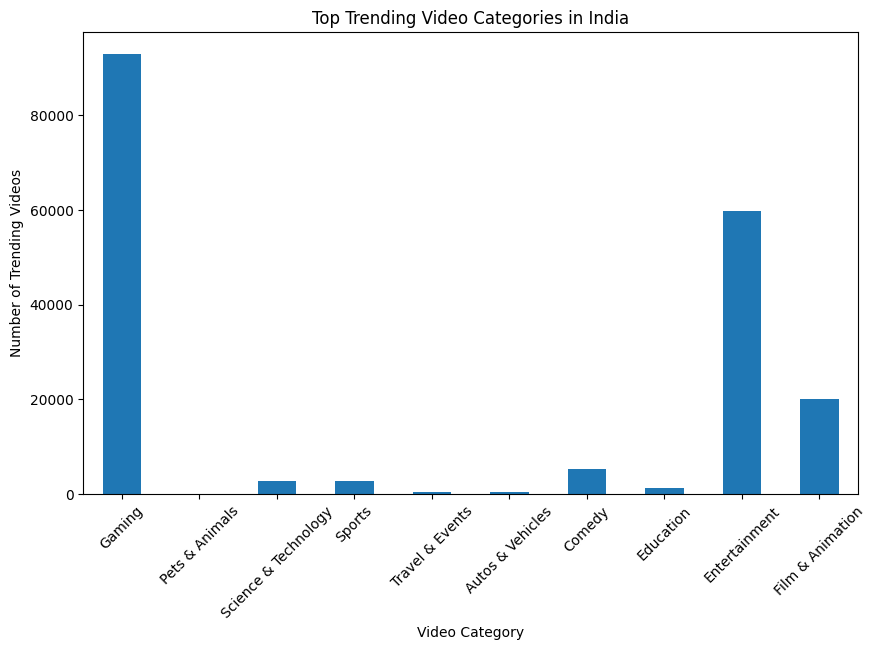

In [59]:
import matplotlib.pyplot as plt

top_categories = clean_df['video_category_id'].value_counts().compute().head(10)

plt.figure(figsize=(10,6))
top_categories.plot(kind='bar')

plt.title("Top Trending Video Categories in India")
plt.xlabel("Video Category")
plt.ylabel("Number of Trending Videos")

plt.xticks(rotation=45)
plt.show()

In [60]:
category_counts = clean_df['video_category_id'].value_counts().compute()
category_counts

video_category_id
Gaming                  92919
Pets & Animals              3
Science & Technology     2874
Sports                   2840
Travel & Events           520
Autos & Vehicles          449
Comedy                   5337
Education                1351
Entertainment           59725
Film & Animation        20017
Howto & Style            1643
Music                   87969
News & Politics          2310
People & Blogs          24823
Name: count, dtype: int64[pyarrow]

In [61]:
category_counts = category_counts.sort_values(ascending=False)
category_counts

video_category_id
Gaming                  92919
Music                   87969
Entertainment           59725
People & Blogs          24823
Film & Animation        20017
Comedy                   5337
Science & Technology     2874
Sports                   2840
News & Politics          2310
Howto & Style            1643
Education                1351
Travel & Events           520
Autos & Vehicles          449
Pets & Animals              3
Name: count, dtype: int64[pyarrow]

In [62]:
top_categories = category_counts.head(10)
top_categories

video_category_id
Gaming                  92919
Music                   87969
Entertainment           59725
People & Blogs          24823
Film & Animation        20017
Comedy                   5337
Science & Technology     2874
Sports                   2840
News & Politics          2310
Howto & Style            1643
Name: count, dtype: int64[pyarrow]

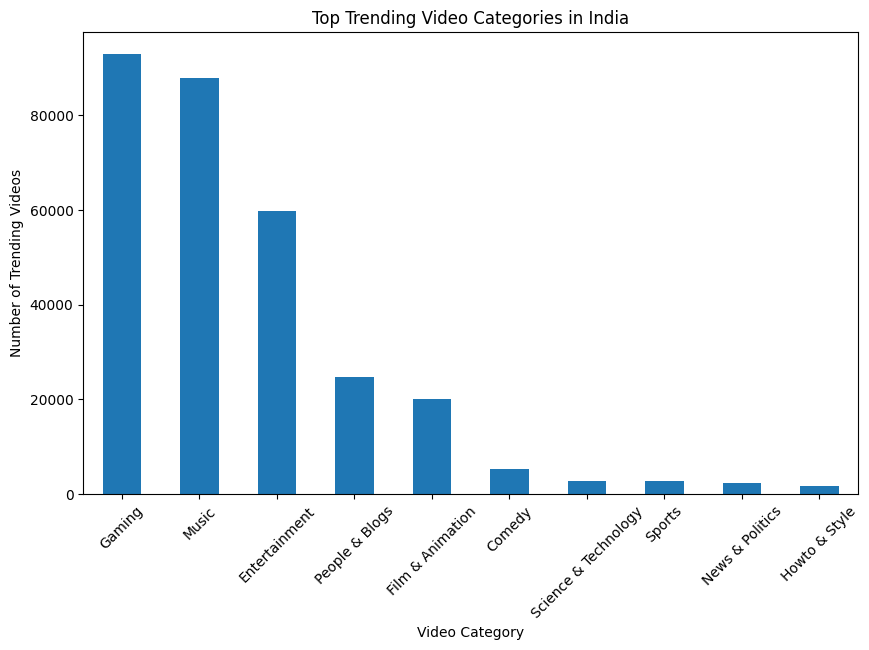

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_categories.plot(kind='bar')

plt.title("Top Trending Video Categories in India")
plt.xlabel("Video Category")
plt.ylabel("Number of Trending Videos")

plt.xticks(rotation=45)

plt.show()

In [ ]:
top_categories.to_csv("../data/trending_categories_india.csv")

In [64]:
clean_df['video_published_at'] = dd.to_datetime(clean_df['video_published_at'])

This converts:2024-10-11T07:26:40Z into a real datetime format.

In [65]:
clean_df['upload_hour'] = clean_df['video_published_at'].dt.hour

In [66]:
clean_df['upload_day'] = clean_df['video_published_at'].dt.day_name()

In [67]:
hour_counts = clean_df['upload_hour'].value_counts().compute().sort_index()

hour_counts

upload_hour
0      5784
1      8063
2      5797
3     10548
4     21382
5     23557
6     15554
7     16849
8     16981
9     14656
10    12800
11    22285
12    32483
13    24880
14    20554
15    14766
16     8536
17     6476
18     4072
19     2940
20     1945
21     2892
22     5207
23     3779
Name: count, dtype: int64

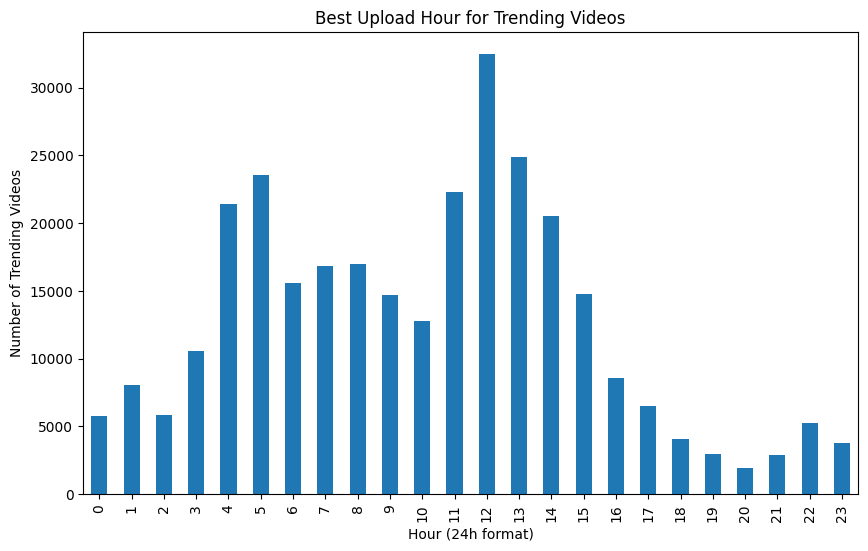

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

hour_counts.plot(kind='bar')

plt.title("Best Upload Hour for Trending Videos")
plt.xlabel("Hour (24h format)")
plt.ylabel("Number of Trending Videos")

plt.show()

In [70]:
day_counts = clean_df['upload_day'].value_counts().compute()

day_counts

upload_day
Saturday     44944
Tuesday      41605
Friday       47235
Monday       42217
Sunday       40774
Thursday     42249
Wednesday    43762
Name: count, dtype: int64

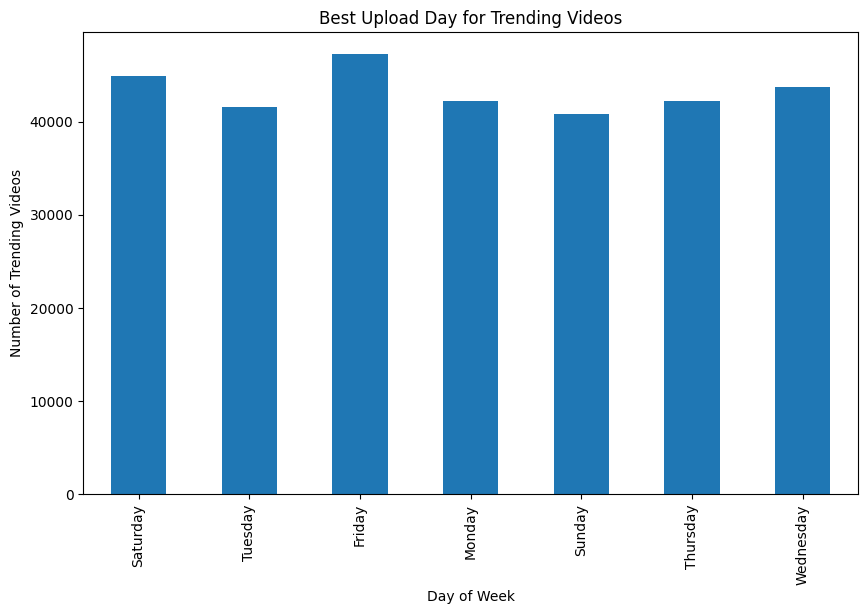

In [71]:
plt.figure(figsize=(10,6))

day_counts.plot(kind='bar')

plt.title("Best Upload Day for Trending Videos")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trending Videos")

plt.show()

In [ ]:
hour_counts.to_csv("../data/best_upload_hour_india.csv")

In [72]:
day_counts = clean_df['upload_day'].value_counts().compute()

In [ ]:
day_counts.to_csv("../data/best_upload_day_india.csv")

In [73]:
import re

def duration_to_minutes(duration):
    if duration is None:
        return None
    
    hours = 0
    minutes = 0
    seconds = 0

    h = re.search(r'(\d+)H', duration)
    m = re.search(r'(\d+)M', duration)
    s = re.search(r'(\d+)S', duration)

    if h:
        hours = int(h.group(1))
    if m:
        minutes = int(m.group(1))
    if s:
        seconds = int(s.group(1))

    total_minutes = hours * 60 + minutes + seconds / 60
    return total_minutes

Convert Duration to Minutes

In [74]:
clean_df['duration_minutes'] = clean_df['video_duration'].apply(
    duration_to_minutes,
    meta=('duration_minutes','float')
)

In [75]:
import pandas as pd

sample_duration = clean_df['duration_minutes'].dropna().compute()

bins = [0,1,3,5,8,10,15,20,30,60,120]
labels = [
    "<1 min","1-3 min","3-5 min","5-8 min",
    "8-10 min","10-15 min","15-20 min",
    "20-30 min","30-60 min","1hr+"
]

duration_groups = pd.cut(sample_duration, bins=bins, labels=labels)

duration_counts = duration_groups.value_counts().sort_index()

duration_counts

duration_minutes
<1 min       52793
1-3 min      52154
3-5 min      53460
5-8 min      15281
8-10 min      8233
10-15 min    21542
15-20 min    17923
20-30 min    22219
30-60 min    22053
1hr+         14850
Name: count, dtype: int64

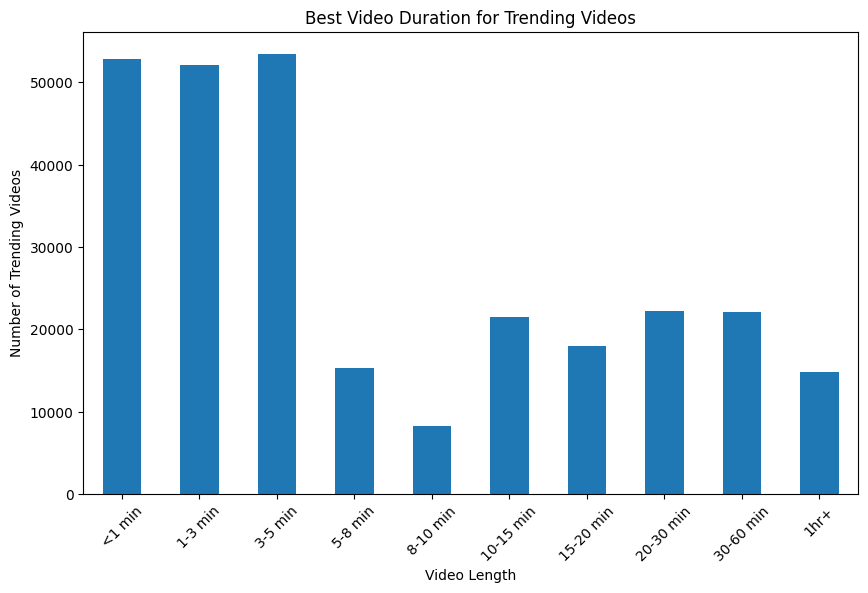

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

duration_counts.plot(kind="bar")

plt.title("Best Video Duration for Trending Videos")
plt.xlabel("Video Length")
plt.ylabel("Number of Trending Videos")

plt.xticks(rotation=45)

plt.show()

In [ ]:
duration_counts.to_csv("../data/best_video_duration_india.csv")

In [77]:
title_sample = clean_df['video_title'].dropna().sample(frac=0.1).compute()

In [78]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    return text

clean_titles = title_sample.apply(clean_text)

In [79]:
all_words = " ".join(clean_titles).split()

In [80]:
from collections import Counter

word_counts = Counter(all_words)

top_words = dict(word_counts.most_common(20))
top_words

{'in': 4138,
 'trailer': 4072,
 'official': 3926,
 '2025': 3235,
 'video': 3155,
 'live': 2886,
 'song': 2640,
 'shorts': 2528,
 'the': 2492,
 'new': 2334,
 'vs': 2286,
 'granny': 1799,
 'i': 1760,
 'gameplay': 1504,
 'teaser': 1470,
 '5': 1375,
 'a': 1368,
 '2': 1296,
 'gta': 1292,
 'minecraft': 1200}

In [81]:
stopwords = {
"in","the","a","i","and","to","of","for","on","with","is","at","by",
"from","this","that","it","an","be","are","was","as"
}

filtered_words = [word for word in all_words if word not in stopwords]

Remove Stopwords

In [82]:
from collections import Counter

word_counts = Counter(filtered_words)

top_words = dict(word_counts.most_common(20))

top_words

{'trailer': 4072,
 'official': 3926,
 '2025': 3235,
 'video': 3155,
 'live': 2886,
 'song': 2640,
 'shorts': 2528,
 'new': 2334,
 'vs': 2286,
 'granny': 1799,
 'gameplay': 1504,
 'teaser': 1470,
 '5': 1375,
 '2': 1296,
 'gta': 1292,
 'minecraft': 1200,
 '1': 1195,
 'franklin': 1126,
 'songs': 1034,
 '2026': 1015}

In [83]:
remove_words = {"2","5","1","franklin"}

filtered_words = [word for word in filtered_words if word not in remove_words]

In [84]:
from collections import Counter

word_counts = Counter(filtered_words)

top_words = dict(word_counts.most_common(20))

top_words

{'trailer': 4072,
 'official': 3926,
 '2025': 3235,
 'video': 3155,
 'live': 2886,
 'song': 2640,
 'shorts': 2528,
 'new': 2334,
 'vs': 2286,
 'granny': 1799,
 'gameplay': 1504,
 'teaser': 1470,
 'gta': 1292,
 'minecraft': 1200,
 'songs': 1034,
 '2026': 1015,
 'free': 998,
 'fire': 954,
 'singh': 952,
 'indian': 950}

In [85]:
top_words_df = pd.DataFrame(list(top_words.items()), columns=["keyword","count"])

In [ ]:
top_words_df.to_csv("../data/trending_keywords_india.csv", index=False)